In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("clean_food_prices.csv")

In [9]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [10]:
pd.read_sql("PRAGMA table_info(food_prices);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,Date,TEXT,0,None,0
1,1,State,TEXT,0,None,0
2,2,LGA,TEXT,0,None,0
3,3,Outlet Type,TEXT,0,None,0
4,4,Country,TEXT,0,None,0
5,5,Sector,TEXT,0,None,0
6,6,Food Item,TEXT,0,None,0
7,7,Price Category,TEXT,0,None,0
8,8,UPRICE,REAL,0,None,0
9,9,Year,INTEGER,0,None,0


In [11]:
df.to_sql("food_prices", conn, if_exists="replace", index=False)

749922

In [12]:
query1 = """
SELECT food_item, AVG(uprice) AS avg_price
FROM food_prices
GROUP BY food_item
ORDER BY avg_price DESC;
"""

In [13]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.to_sql("food_prices", conn, if_exists="replace", index=False)

749922

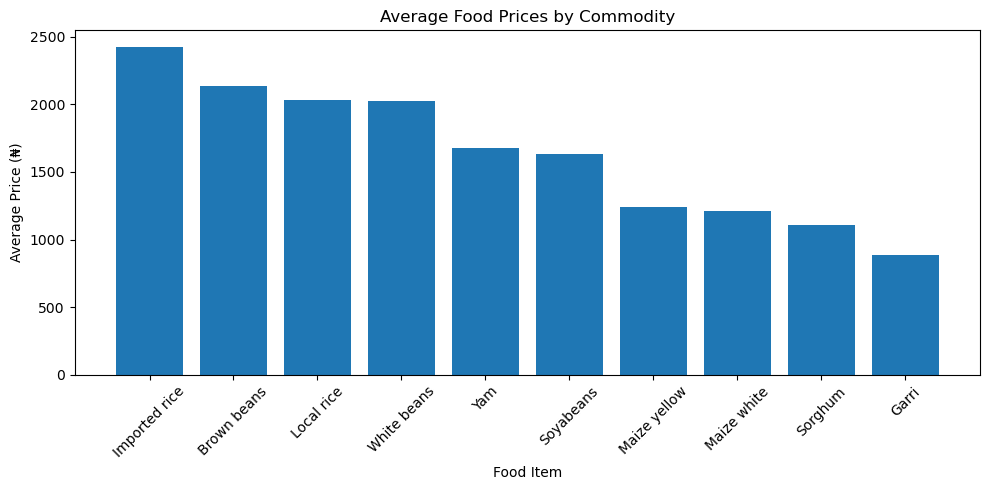

In [15]:
plt.figure(figsize=(10,5))

plt.bar(df1['food_item'], df1['avg_price'])

plt.title("Average Food Prices by Commodity")
plt.xlabel("Food Item")
plt.ylabel("Average Price (₦)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [16]:
query2 = """
SELECT state, AVG(uprice) AS avg_price
FROM food_prices
GROUP BY state
ORDER BY avg_price DESC;
"""

df2 = pd.read_sql(query2, conn)

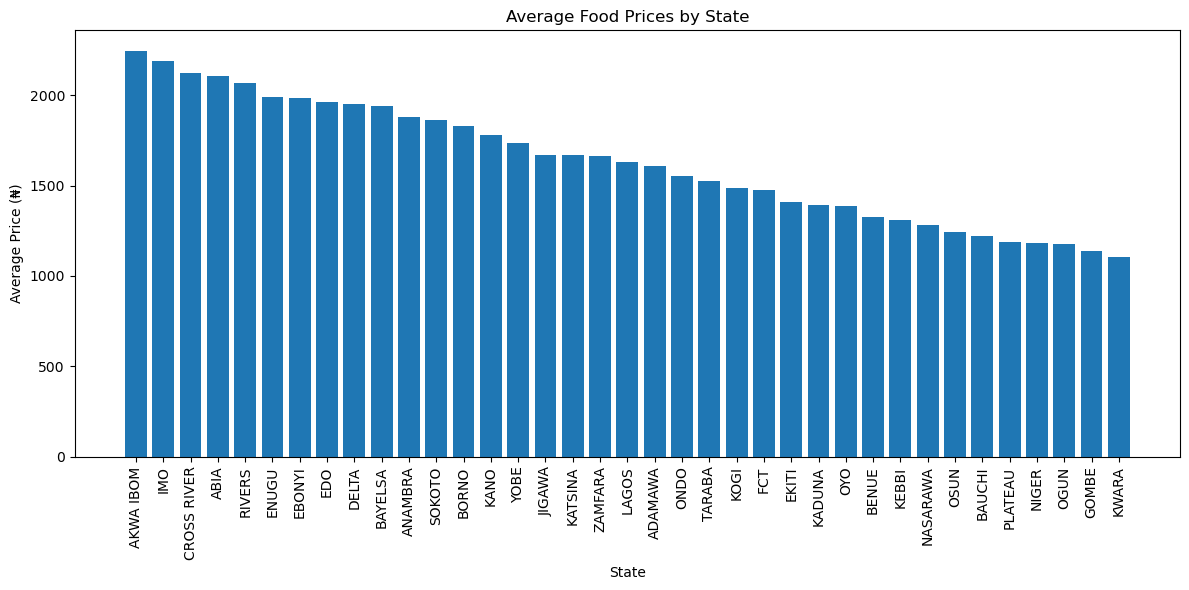

In [17]:
plt.figure(figsize=(12,6))

plt.bar(df2['state'], df2['avg_price'])

plt.title("Average Food Prices by State")
plt.xlabel("State")
plt.ylabel("Average Price (₦)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [18]:
query3 = """
SELECT sector, AVG(uprice) AS avg_price
FROM food_prices
GROUP BY sector;
"""

df3 = pd.read_sql(query3, conn)

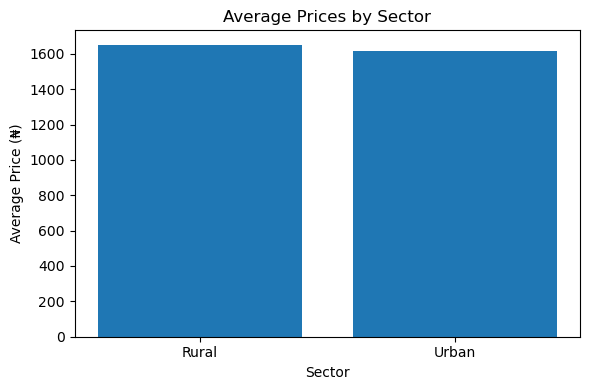

In [19]:
plt.figure(figsize=(6,4))

plt.bar(df3['sector'], df3['avg_price'])

plt.title("Average Prices by Sector")
plt.xlabel("Sector")
plt.ylabel("Average Price (₦)")

plt.tight_layout()
plt.show()

In [20]:
query4 = """
SELECT date, AVG(uprice) AS avg_price
FROM food_prices
GROUP BY date
ORDER BY date;
"""

df_time = pd.read_sql(query4, conn)

df_time['date'] = pd.to_datetime(df_time['date'])

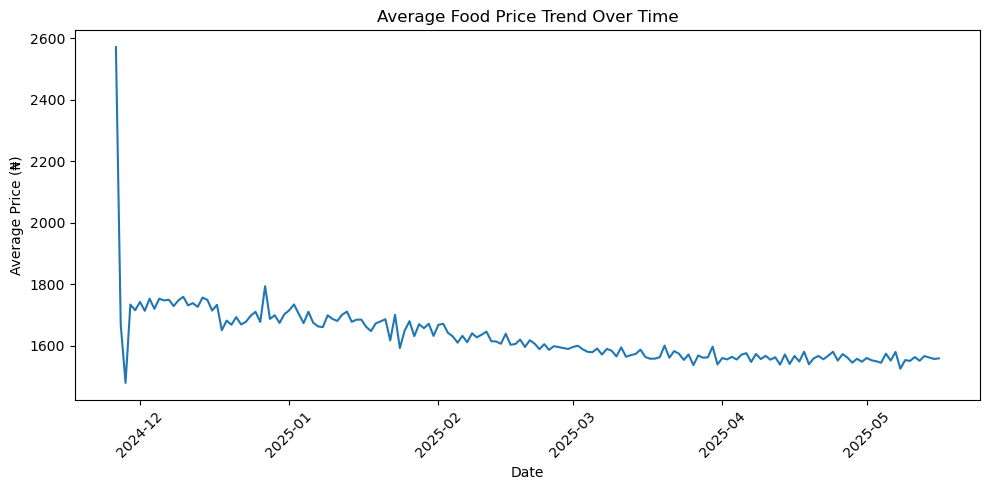

In [21]:
plt.figure(figsize=(10,5))

plt.plot(df_time['date'], df_time['avg_price'])

plt.title("Average Food Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price (₦)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

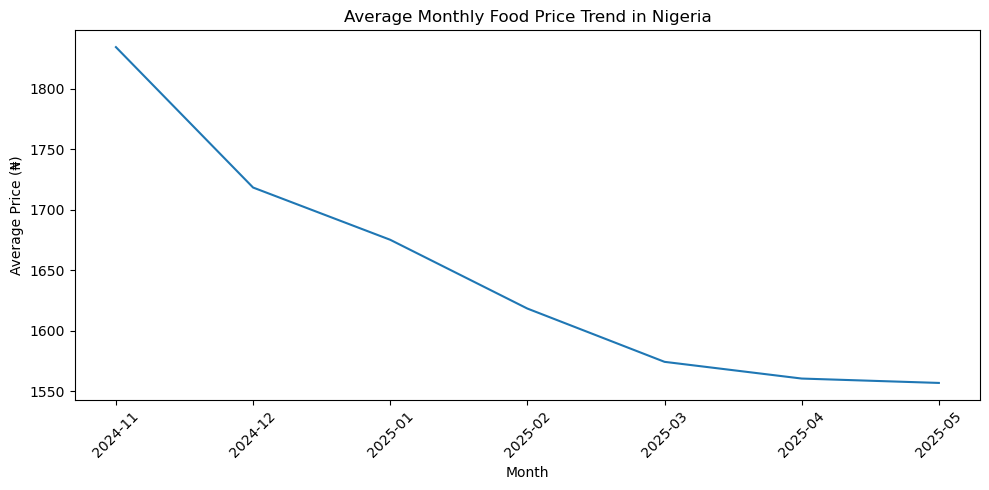

In [22]:
df_time['month'] = df_time['date'].dt.to_period('M')

df_monthly = df_time.groupby('month')['avg_price'].mean()

plt.figure(figsize=(10,5))

plt.plot(df_monthly.index.astype(str), df_monthly.values)

plt.title("Average Monthly Food Price Trend in Nigeria")
plt.xlabel("Month")
plt.ylabel("Average Price (₦)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
query4 = """
SELECT outlet_type, AVG(uprice) AS avg_price
FROM food_prices
GROUP BY outlet_type
ORDER BY avg_price DESC;
"""

df4 = pd.read_sql(query4, conn)

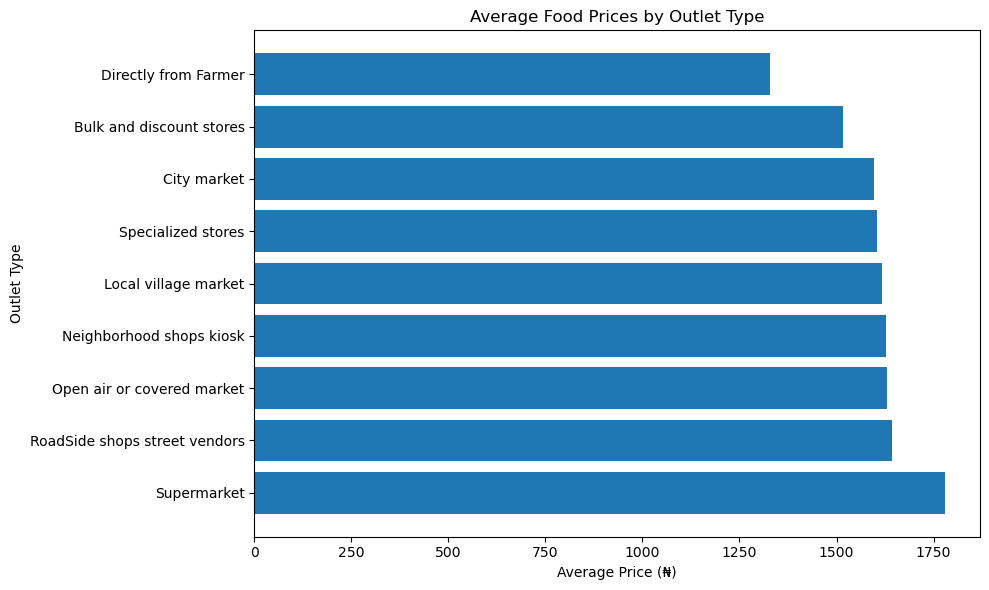

In [25]:
plt.figure(figsize=(10,6))

plt.barh(df4['outlet_type'], df4['avg_price'])

plt.title("Average Food Prices by Outlet Type")
plt.xlabel("Average Price (₦)")
plt.ylabel("Outlet Type")

plt.tight_layout()
plt.show()

In [26]:
region_map = {
    # South West
    "LAGOS": "South West",
    "OGUN": "South West",
    "OYO": "South West",
    "OSUN": "South West",
    "ONDO": "South West",
    "EKITI": "South West",

    # South East
    "ABIA": "South East",
    "ANAMBRA": "South East",
    "EBONYI": "South East",
    "ENUGU": "South East",
    "IMO": "South East",

    # South South
    "RIVERS": "South South",
    "DELTA": "South South",
    "AKWA IBOM": "South South",
    "BAYELSA": "South South",
    "CROSS RIVER": "South South",
    "EDO": "South South",

    # North Central
    "FCT": "North Central",
    "BENUE": "North Central",
    "KOGI": "North Central",
    "KWARA": "North Central",
    "NIGER": "North Central",
    "PLATEAU": "North Central",
    "NASARAWA": "North Central",

    # North West
    "KANO": "North West",
    "KADUNA": "North West",
    "KATSINA": "North West",
    "KEBBI": "North West",
    "SOKOTO": "North West",
    "ZAMFARA": "North West",
    "JIGAWA": "North West",

    # North East
    "BORNO": "North East",
    "YOBE": "North East",
    "ADAMAWA": "North East",
    "TARABA": "North East",
    "BAUCHI": "North East",
    "GOMBE": "North East"
}

In [27]:
df['region'] = df['state'].map(region_map)

In [28]:
df_region = df.groupby('region')['uprice'].mean().reset_index()
df_region = df_region.sort_values(by='uprice')

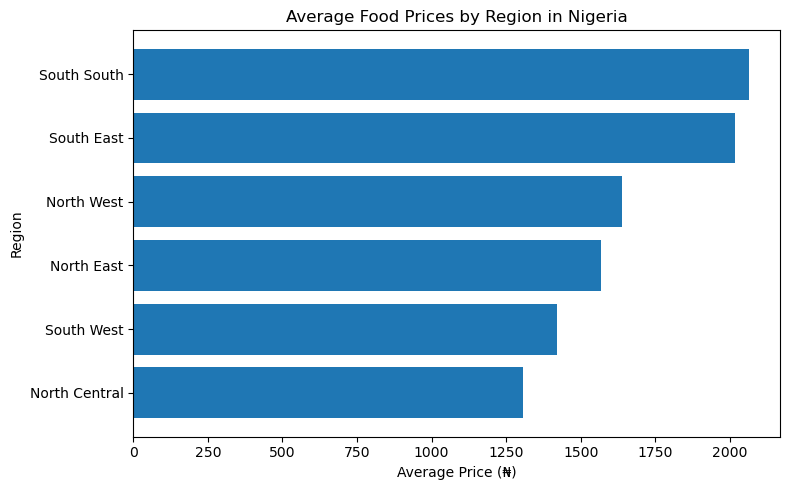

In [29]:
plt.figure(figsize=(8,5))

plt.barh(df_region['region'], df_region['uprice'])

plt.title("Average Food Prices by Region in Nigeria")
plt.xlabel("Average Price (₦)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

In [30]:
df['macro_region'] = df['region'].apply(
    lambda x: "North" if "North" in str(x) else "South"
)

df_macro = df.groupby('macro_region')['uprice'].mean().reset_index()

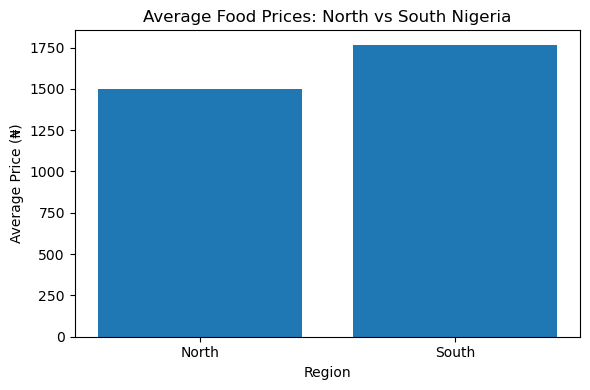

In [31]:
plt.figure(figsize=(6,4))

plt.bar(df_macro['macro_region'], df_macro['uprice'])

plt.title("Average Food Prices: North vs South Nigeria")
plt.xlabel("Region")
plt.ylabel("Average Price (₦)")

plt.tight_layout()
plt.show()